# **Name: MD ABU SAYEM**
# **Roll: 25/SET/MTCE/014**

# **Experiment_3B: Multiple Linear Regression Analysis**

Problem Statement: In this experiment, the objective is to study and analyze a Multiple Linear Regression model using both manual computation and Python library methods.

The dataset consists of the following independent variables:

* Weight (kg)
* Blood Pressure (BP)
* Cholesterol Level
* Age (years)

and one dependent variable: **Final Score**

Objectives:

1. To calculate the mean of all variables and compute their deviations from the mean.
2. To determine the intercept (b₀) and regression coefficients and derive the final linear regression equation:
   * (a) Manually
   * (b) Using Python libraries
3. To predict the final score for a person having:
   * Weight = 72 kg
   * Blood Pressure = 138
   * Cholesterol = 220
   * Age = 48 years
4. To evaluate the regression model by calculating:
   * R² (Coefficient of Determination)
   * Variance Inflation Factor (VIF)
   * Tolerance Factor
5. To interpret the obtained results and comment on the model performance and multicollinearity.

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [33]:
data = {
    "Weight": [60,65,70,75,80],
    "BP": [120,125,130,140,150],
    "Cholesterol": [180,190,200,220,240],
    "Age": [40,42,45,50,55],
    "RiskScore": [65,68,72,78,85]
}

df = pd.DataFrame(data)
df

,Weight,BP,Cholesterol,Age,RiskScore
0,60,120,180,40,65
1,65,125,190,42,68
2,70,130,200,45,72
3,75,140,220,50,78
4,80,150,240,55,85


In [34]:
means = df.mean()
deviations = df - means
print("MEAN OF VARIABLES:\n", means)
print("\nDEVIATIONS FROM MEAN:\n", deviations)

MEAN OF VARIABLES:
 Weight          70.0
BP             133.0
Cholesterol    206.0
Age             46.4
RiskScore       73.6
dtype: float64

DEVIATIONS FROM MEAN:
    Weight    BP  Cholesterol  Age  RiskScore
0   -10.0 -13.0        -26.0 -6.4       -8.6
1    -5.0  -8.0        -16.0 -4.4       -5.6
2     0.0  -3.0         -6.0 -1.4       -1.6
3     5.0   7.0         14.0  3.6        4.4
4    10.0  17.0         34.0  8.6       11.4


In [35]:
X = df[["Weight","BP","Cholesterol","Age"]].values
Y = df["RiskScore"].values

X_manual = np.column_stack((np.ones(len(X)), X))
beta = np.linalg.inv(X_manual.T @ X_manual) @ X_manual.T @ Y

print("Intercept (b0):", beta[0])
print("Coefficients (b1..b4):", beta[1:])

Intercept (b0): 132.06638733803635
Coefficients (b1..b4): [ 5.48352778 -4.08093211  1.27435294  0.83333333]


In [36]:
X_lib = df[["Weight","BP","Cholesterol","Age"]]
Y_lib = df["RiskScore"]

X_const = sm.add_constant(X_lib)
model = sm.OLS(Y_lib, X_const).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              RiskScore   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                     514.1
Date:                Sun, 01 Feb 2026   Prob (F-statistic):             0.0324
Time:                        15:27:39   Log-Likelihood:                 1.4083
No. Observations:                   5   AIC:                             5.183
Df Residuals:                       1   BIC:                             3.621
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0117      0.012      0.948      

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [37]:
new_data = pd.DataFrame({
    "const":[1],
    "Weight":[72],
    "BP":[138],
    "Cholesterol":[220],
    "Age":[48]
})

predicted_score = model.predict(new_data)
print("Predicted Final Risk Score:", round(predicted_score[0],2))

Predicted Final Risk Score: 75.82


In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# R-squared
print("R² (Coefficient of Determination):", round(model.rsquared, 4))

# VIF & Tolerance
vif_df = pd.DataFrame()
vif_df["Feature"] = X_lib.columns
vif_df["VIF"] = [variance_inflation_factor(X_lib.values, i)
                 for i in range(X_lib.shape[1])]
vif_df["Tolerance"] = 1 / vif_df["VIF"]

vif_df

R² (Coefficient of Determination): 0.9994


,Feature,VIF,Tolerance
0,Weight,33.333333,0.030000
1,BP,21201.138889,0.000047
2,Cholesterol,160060.694444,0.000006
3,Age,870.333333,0.001149


In [39]:
# R-squared
print("R² (Coefficient of Determination):", round(model.rsquared, 4))

# VIF and Tolerance (printed values)
for i, feature in enumerate(X_lib.columns):
    vif = variance_inflation_factor(X_lib.values, i)
    tolerance = 1 / vif

    print(f"{feature} -> VIF: {vif:.4f}, Tolerance: {tolerance:.4f}")

R² (Coefficient of Determination): 0.9994
Weight -> VIF: 33.3333, Tolerance: 0.0300
BP -> VIF: 21201.1389, Tolerance: 0.0000
Cholesterol -> VIF: 160060.6944, Tolerance: 0.0000
Age -> VIF: 870.3333, Tolerance: 0.0011


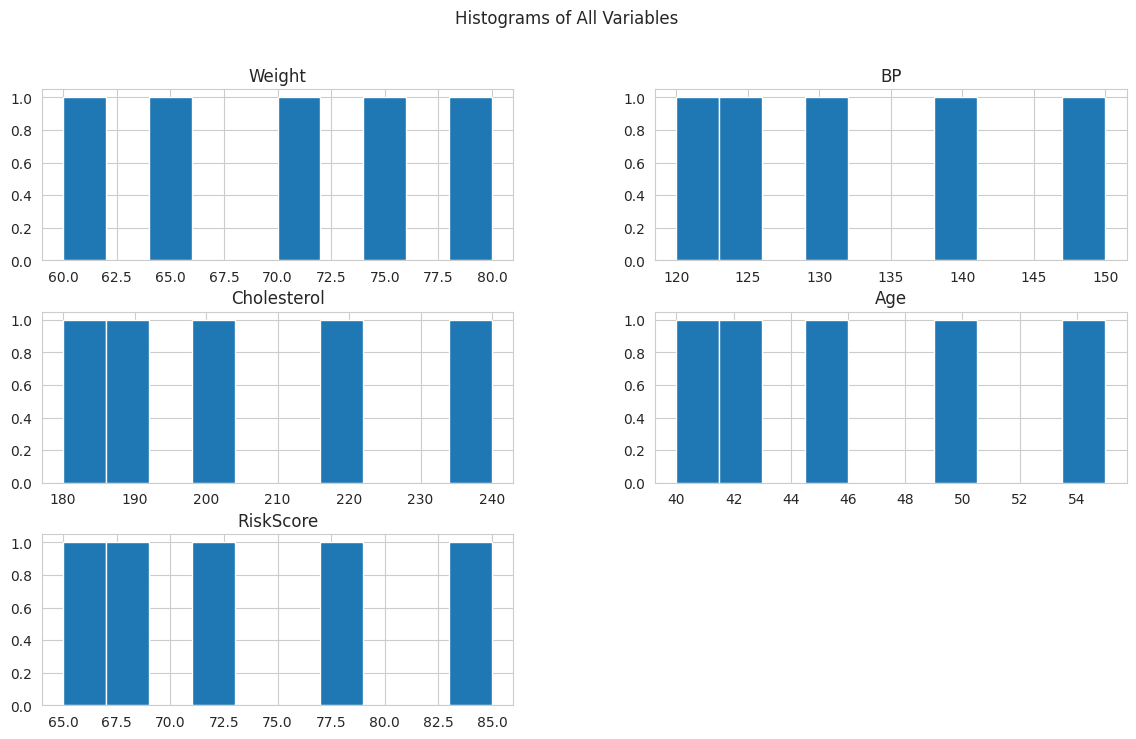

In [40]:
df.hist(figsize=(14,8))
plt.suptitle("Histograms of All Variables")
plt.show()

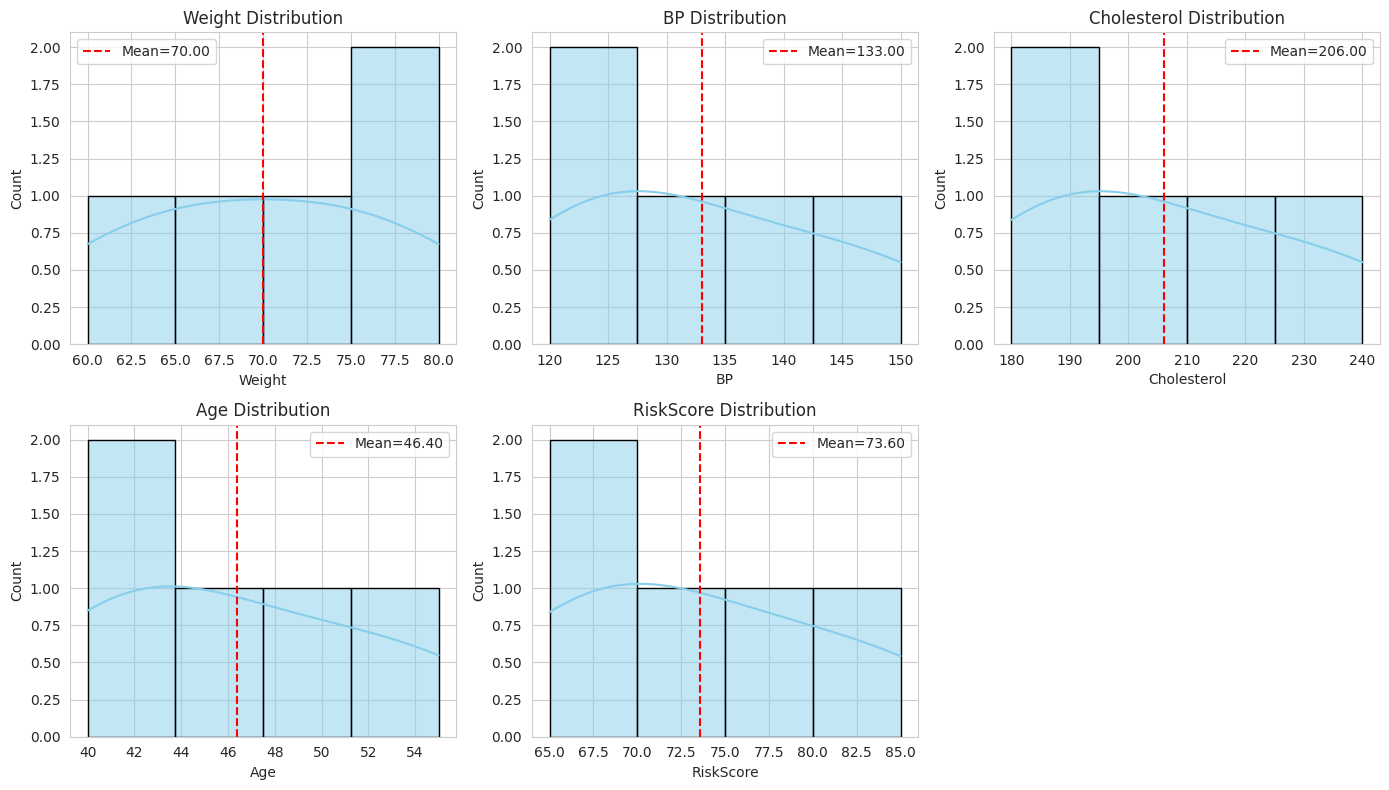

In [41]:
# Histograms with Mean Lines
plt.figure(figsize=(14,8))
for i, col in enumerate(df.columns):
    plt.subplot(2,3,i+1)
    sns.histplot(df[col], kde=True, color='skyblue', edgecolor='black')
    plt.axvline(means[col], color='red', linestyle='--', label=f"Mean={means[col]:.2f}")
    plt.title(f"{col} Distribution")
    plt.legend()
plt.tight_layout()
plt.show()

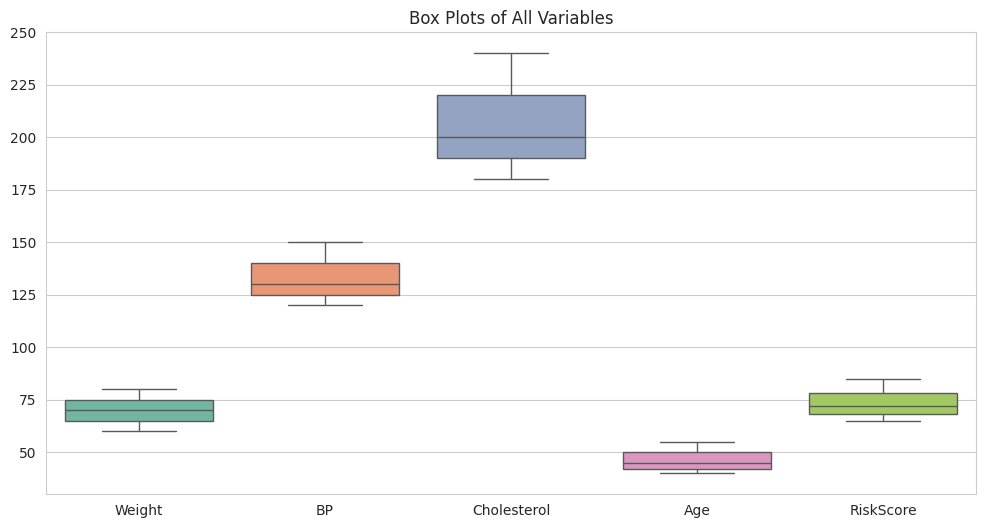

In [42]:
# Box Plots (Colored)
plt.figure(figsize=(12,6))
sns.boxplot(data=df, palette="Set2")
plt.title("Box Plots of All Variables")
plt.show()

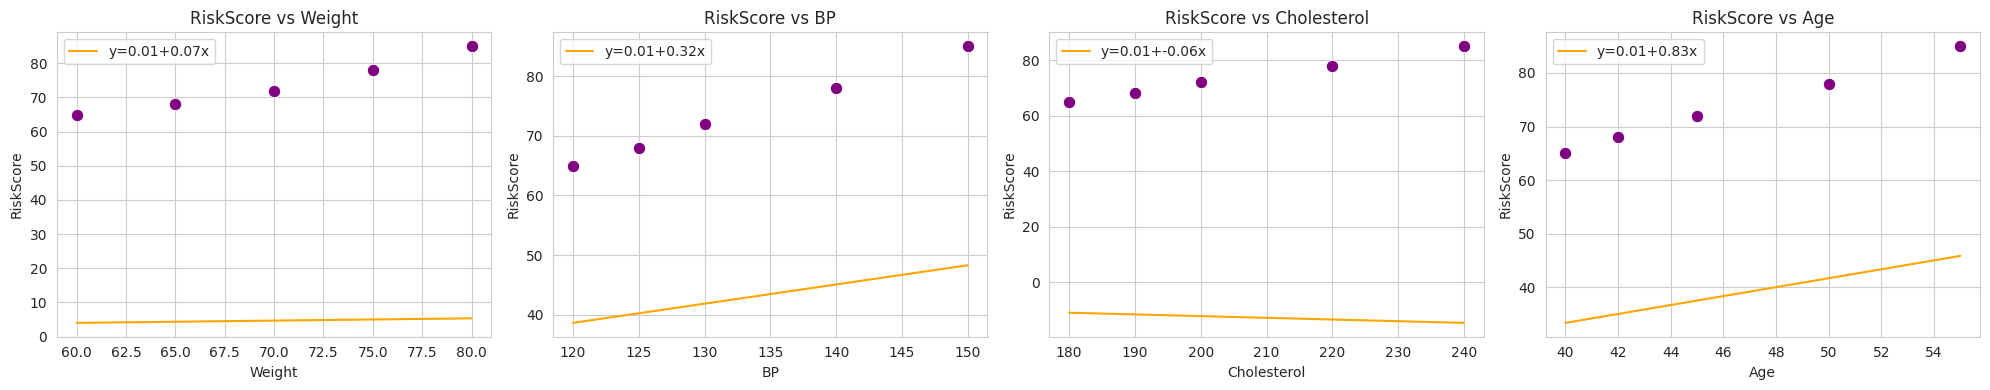

In [43]:
# Scatter Plots with Regression Line & Equation
fig, axes = plt.subplots(1,4, figsize=(20,4))
predictors = ["Weight","BP","Cholesterol","Age"]

for i, feature in enumerate(predictors):
    sns.scatterplot(x=df[feature], y=Y_lib, ax=axes[i], color='purple', s=80)

    # Regression line
    coef = model.params
    slope = coef[feature]
    intercept = coef["const"]
    x_vals = np.array(df[feature])
    y_vals = intercept + slope*x_vals
    axes[i].plot(x_vals, y_vals, color='orange', label=f"y={intercept:.2f}+{slope:.2f}x")

    axes[i].set_title(f"RiskScore vs {feature}")
    axes[i].legend()

plt.tight_layout()
plt.show()

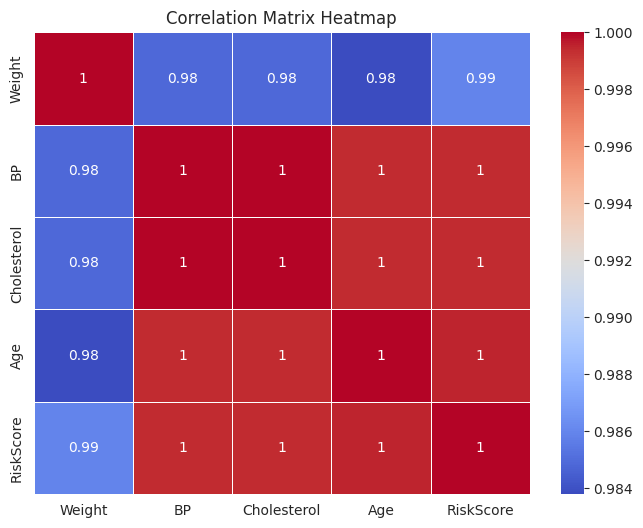

In [44]:
# Correlation Matrix Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

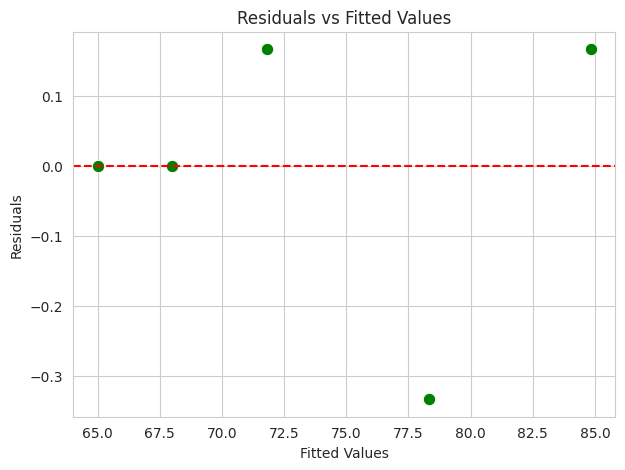

In [45]:
# Residuals Plot
fitted_values = model.predict(X_const)
residuals = Y_lib - fitted_values

plt.figure(figsize=(7,5))
sns.scatterplot(x=fitted_values, y=residuals, color='green', s=80)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

In [46]:
# SUMMARY
print("DISTRIBUTION ANALYSIS SUMMARY")
print("-"*50)
for col in df.columns:
    print(f"• {col}: Range {df[col].min()}-{df[col].max()}, Mean={means[col]:.2f}")

print("\nCorrelation Matrix:\n", df.corr())
print("\nR² Value:", model.rsquared)
print("\nVIF & Tolerance:\n", vif_df)
print("\nPredicted Risk Score for new data:", round(predicted_score[0],2))

DISTRIBUTION ANALYSIS SUMMARY
--------------------------------------------------
• Weight: Range 60-80, Mean=70.00
• BP: Range 120-150, Mean=133.00
• Cholesterol: Range 180-240, Mean=206.00
• Age: Range 40-55, Mean=46.40
• RiskScore: Range 65-85, Mean=73.60

Correlation Matrix:
                Weight        BP  Cholesterol       Age  RiskScore
Weight       1.000000  0.984798     0.984798  0.983783   0.985904
BP           0.984798  1.000000     1.000000  0.999422   0.999397
Cholesterol  0.984798  1.000000     1.000000  0.999422   0.999397
Age          0.983783  0.999422     0.999422  1.000000   0.999523
RiskScore    0.985904  0.999397     0.999397  0.999523   1.000000

R² Value: 0.9993519958527735

VIF & Tolerance:
        Feature            VIF  Tolerance
0       Weight      33.333333   0.030000
1           BP   21201.138889   0.000047
2  Cholesterol  160060.694444   0.000006
3          Age     870.333333   0.001149

Predicted Risk Score for new data: 75.82
